## Convolutional Networks

We'll check out how to build a **convolutional network** to classify CIFAR10 images. By using weight sharing - multiple units with the same weights - convolutional layers are able to learn repeated patterns in your data. For example, a unit could learn the pattern for an eye, or a face, or lower level features like edges.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import numpy as np
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import torch.utils.data as utils
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.datasets import CIFAR10

%matplotlib inline

In [ ]:
label_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "bird", "ship", "truck"]


def plot_images(images, cls_true, cls_pred=None):
    """
    Adapted from https://github.com/Hvass-Labs/TensorFlow-Tutorials/
    """
    fig, axes = plt.subplots(3, 3)

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation="spline16")

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(cls_true_name, cls_pred_name)
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.4].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.69803923].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08

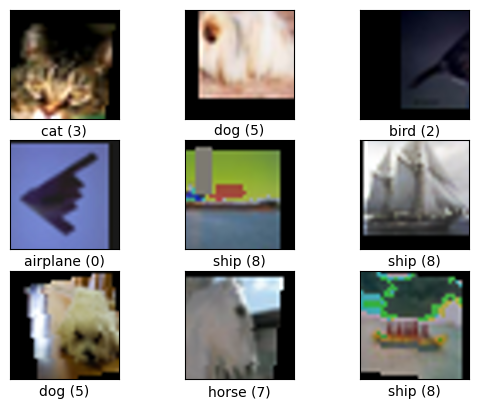

In [3]:
def get_train_valid_loader(
    data_dir="data",
    batch_size=64,
    augment=True,
    random_seed=1,
    valid_size=0.02,
    shuffle=True,
    show_sample=True,
    num_workers=4,
    pin_memory=False,
):
    """
    Utility function for loading and returning train and valid
    multi-process iterators over the CIFAR-10 dataset. A sample
    9x9 grid of the images can be optionally displayed.
    If using CUDA, num_workers should be set to 1 and pin_memory to True.
    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - augment: whether to apply the data augmentation scheme
      mentioned in the paper. Only applied on the train split.
    - random_seed: fix seed for reproducibility.
    - valid_size: percentage split of the training set used for
      the validation set. Should be a float in the range [0, 1].
    - shuffle: whether to shuffle the train/validation indices.
    - show_sample: plot 9x9 sample grid of the dataset.
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    Returns
    -------
    - train_loader: training set iterator.
    - valid_loader: validation set iterator.
    """
    error_msg = "[!] valid_size should be in the range [0, 1]."
    assert (valid_size >= 0) and (valid_size <= 1), error_msg

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # define transforms for validation (no augmentation)
    valid_transform = transforms.Compose(
        [
            transforms.ToTensor(),
            normalize,
        ]
    )

    # Define the transform for training (and data augmentation)
    if augment:
        train_transform = transforms.Compose(
            [
                transforms.RandomCrop(32, padding=4),
                transforms.RandomHorizontalFlip(),
                transforms.RandAugment(num_ops=2, magnitude=9), 
                transforms.ToTensor(),
                normalize,
                transforms.RandomErasing(p=0.25),
            ]
        )
    else:
        train_transform = transforms.Compose(
            [
                transforms.ToTensor(),
                normalize,
            ]
        )

    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=train_transform,
    )

    valid_dataset = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=valid_transform,
    )

    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset,
        batch_size=batch_size,
        sampler=valid_sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    # visualize some images if requested
    if show_sample:
        sample_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=9,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory,
        )
        data_iter = iter(sample_loader)
        images, labels = next(data_iter)
        # Unnormalize the images for display
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]
        unnorm_images = [unnormalize(img, mean, std) for img in images]
        X = torch.stack(unnorm_images).numpy().transpose([0, 2, 3, 1])
        plot_images(X, labels)

    return (train_loader, valid_loader)


def unnormalize(img, mean, std):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return img


trainloader, valloader = get_train_valid_loader(augment=True, num_workers=1, pin_memory=True)

# Convolutional Neural Network Architecture

Let's first talk about the overall architecture of a CNN and how each dimension evolves after each layer, we'll take as example the first and famous CNN LeNet5 :
<figure align="center">
  <img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/10/image-17.png" alt="LeNet5 Architecture" width="600">
  <figcaption>Image credit: <a href="https://en.wikipedia.org">Wikipedia</a></figcaption>
</figure>

For that, we will have some quick questions to see if you understand what happens during training/inference:

### 1. First Layer Convolution

If we consider the input of LeNet5 to be CIFAR-10, what would be the shape of the parameters of the first convolutional layer (stride = 1)?

- **A.** `torch.Size([6, 1, 5, 5])`
- **B.** `torch.Size([6, 3, 3, 3])`
- **C.** `torch.Size([6, 1, 5, 5])`
- **D.** `torch.Size([6, 3, 5, 5])`

**Answer: D**

C1 = 6 filters @ 28x28, coming from CIFAR input of 3 channels (RGB) and resolution 32x32p.
- 32x32 -> 28x28 with stride=1 and no padding => 5x5 kernel size
- 3 channels in input => 3 channels in filters
- 6 filters => 6 output channels

So the shape of the parameters of the first convolutional layer is `(6, 3, 5, 5)` (= option **D**).

---

### 2. Subsampling Window

What is the shape of the subsampling window (stride = 2) for the second layer (between C1 and C2), and does this shape remain invariant regardless of the subsampling method (e.g., Avg pooling or Max pooling)?

- **A.** `2x2, yes it does`
- **B.** `3x3, no it doesn't`
- **C.** `2x2, no it doesn't`
- **D.** `yes, it does`

**Answer: A**

C1 -> S2: 6 filters @ 28x28 -> 6 filters @ 14x14 with stride=2 and no padding => 2x2 window size.

The subsampling window size remains invariant regardless of the subsampling method (e.g., Avg pooling or Max pooling) as long as the stride and padding are the same (= option **A**).

---

### 3. Backpropagation for Convolutional Filters

Do the filters in the convolutional layers also benefit from backpropagation?

**Answer: Yes**

The filters in the convolutional layers contain trainable weights. Backpropagation computes the gradients of the error w.r.t. these weights, allowing the optimizer to update them in order to minimize the loss function and learn meaningful features from the data.

---

### 4. Role of the Fully-Connected Layer

Explain in your own words why it is necessary to have a fully-connected layer in the architecture.

**Answer:**

The convolutional layers are feature extractors that learn spatial hierarchies of patterns  from the input image - think edges, shapes, textures, etc. A fully-connected layer is necessary to act as a classifier on top of these extracted features. It takes the flattened, high-level spatial features from the final convolutional layer and learns the non-linear combinations required to map them to the final output classes (e.g., the 10 categories in CIFAR-10). We _could_ add more fully-connected layers to increase the network's capacity to learn this mapping, but in doing so we also significantly increase the number of parameters, which can lead to a higher risk of overfitting.

---

If you had any struggle to answer one of theses questions, feel free to ask a TA about intuition or hints about the solution.

# Build your own Convolutional Neural Network Architecture

## Different ways to improve the accuracy of your network :
- Change the number of convolutions and layers (you can take inspiration from internet as you as you cite the architecture)
- Change the optmizer / its hyperparameters
- Add new types of layers
- Do some data augmentation in the get_train_valid_loader function (flipped, cropped, uncentered images) cf. https://pytorch.org/vision/stable/transforms.html


In [4]:
IMG_RES = 32


# Taking inspiration from the ResNet architecture, I'm using a residual block for a deep ConvNet architecture:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # First (Conv2d -> BatchNorm -> GELU)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act1 = nn.GELU()

        # Second (Conv2d -> BatchNorm -> GELU)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # With shortcut connection (either identity or projection, depending on stride/dim change)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        self.act2 = nn.GELU()

    def forward(self, x):
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.act2(out)
        return out


class ConvNet(nn.Module):
    def __init__(self, n_input_channels=3, n_output=10):
        super().__init__()

        # Convolution trunk to extract features from input image
        self.features = nn.Sequential(
            # 1. Input (CIFAR10 image, 32x32p RGB) -> Conv2d -> BatchNorm -> GELU
            nn.Conv2d(n_input_channels, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            # 2. Residual Blocks
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 128, stride=2),  # Downsample to 16x16
            ResidualBlock(128, 128, stride=1),
            ResidualBlock(128, 256, stride=2),  # Downsample to 8x8
            ResidualBlock(256, 256, stride=1),
            ResidualBlock(256, 512, stride=2),  # Downsample to 4x4
        )

        # 3. Global Average Pooling and classification head
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),  # One dropout before classification layer
            nn.Linear(512, n_output),
        )

    def forward(self, x):
        # Pass input through convolution trunk -> global avg pooling -> classification head
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)  # Flatten the tensor before FC layer
        x = self.classifier(x)
        return x

    def predict(self, x):
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

In [5]:
import copy

# Ensure we're using GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Initialize the model, loss function, and optimizer
net = ConvNet().to(device)  # Load ConvNet (to GPU if available)

# Loss function: Cross-entropy loss - standard for multi-class classification
#  -> With label smoothing prevents overconfidence => better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer: AdamW = Adam w/ decoupled weight decay - often better for vision tasks
optimizer = optim.AdamW(net.parameters(), lr=3e-3, weight_decay=2e-4)

epochs = 80  # Increased from 10 to 80 because was still learning
steps = 0

# Set up learning rate scheduler to dynamically adjust lr during training and (hopefully) improve perf/convergence
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-3, steps_per_epoch=len(trainloader), epochs=epochs, pct_start=0.2
)

# Track metrics for plotting
train_losses = []
valid_accuracies = []

best_accuracy = 0.0
best_model_wts = copy.deepcopy(net.state_dict())

for e in range(epochs):
    start = time.time()
    running_loss = 0
    epoch_steps = 0

    for images, labels in iter(trainloader):
        # Move inputs and label tensors to the default device
        images, labels = images.to(device), labels.to(device)

        steps += 1
        epoch_steps += 1

        # Forward pass & loss
        optimizer.zero_grad()  # Zero out gradients so they don't accumulate
        output = net(images)  # Forward pass = compute output class logits from network
        loss = criterion(output, labels)  # Calculate loss

        # Backward pass & update
        loss.backward()  # Backprop loss & compute gradients w.r.t parameters
        optimizer.step()  # Step with the optimizer to update weights

        running_loss += loss.item()

    # End of epoch: Validation & Recording Metrics
    stop = time.time()
    avg_train_loss = running_loss / epoch_steps
    train_losses.append(avg_train_loss)

    # Turn on evaluation mode
    net.eval()

    accuracy = 0
    # Turn off gradients for validation
    with torch.no_grad():
        for ii, (images, labels) in enumerate(valloader):
            images, labels = images.to(device), labels.to(device)

            val_output = net(images)
            ps = torch.exp(val_output)
            top_p, top_class = ps.topk(1, dim=1)

            equals = top_class == labels.view(*top_class.shape)
            target_type = torch.FloatTensor if not torch.cuda.is_available() else torch.cuda.FloatTensor
            accuracy += torch.mean(equals.type(target_type)).item()

    avg_valid_acc = accuracy / len(valloader)
    valid_accuracies.append(avg_valid_acc)

    # Check if this is the best model so far
    if avg_valid_acc > best_accuracy:
        best_accuracy = avg_valid_acc
        best_model_wts = copy.deepcopy(net.state_dict())

    print(
        "Epoch: {}/{}..".format(e + 1, epochs),
        "Loss: {:.4f}..".format(avg_train_loss),
        "Test accuracy: {:.4f}..".format(avg_valid_acc),
        "{:.4f} s/batch".format((stop - start) / epoch_steps),
    )

    # Reset to training mode for next epoch
    net.train()

# Load best weights back into the model before returning
print(f"Loading best weights with validation accuracy: {best_accuracy:.4f}")
net.load_state_dict(best_model_wts)

# Save the model
save_path = 'cifar10_best_convnet.pth'
torch.save(net.state_dict(), save_path)
print(f"Model saved to {save_path}")

Training on device: cuda
Epoch: 1/80.. Loss: 1.7663.. Test accuracy: 0.6123.. 0.0316 s/batch
Epoch: 2/80.. Loss: 1.4298.. Test accuracy: 0.7000.. 0.0303 s/batch
Epoch: 3/80.. Loss: 1.2697.. Test accuracy: 0.7785.. 0.0306 s/batch
Epoch: 4/80.. Loss: 1.1811.. Test accuracy: 0.7750.. 0.0303 s/batch
Epoch: 5/80.. Loss: 1.1208.. Test accuracy: 0.8285.. 0.0300 s/batch
Epoch: 6/80.. Loss: 1.0744.. Test accuracy: 0.8377.. 0.0301 s/batch
Epoch: 7/80.. Loss: 1.0327.. Test accuracy: 0.8318.. 0.0303 s/batch
Epoch: 8/80.. Loss: 1.0066.. Test accuracy: 0.8609.. 0.0303 s/batch
Epoch: 9/80.. Loss: 0.9759.. Test accuracy: 0.8668.. 0.0305 s/batch
Epoch: 10/80.. Loss: 0.9508.. Test accuracy: 0.8752.. 0.0302 s/batch
Epoch: 11/80.. Loss: 0.9302.. Test accuracy: 0.8824.. 0.0304 s/batch
Epoch: 12/80.. Loss: 0.9139.. Test accuracy: 0.8766.. 0.0302 s/batch
Epoch: 13/80.. Loss: 0.8972.. Test accuracy: 0.8854.. 0.0302 s/batch
Epoch: 14/80.. Loss: 0.8823.. Test accuracy: 0.8895.. 0.0303 s/batch
Epoch: 15/80.. Los

Nice! 94.5% validation accuracy after 80 epochs (= ~35 minutes) of training on my laptop's RTX 5050.

Here's a little summary of the architecture and param count:

In [6]:
print(net)
param_count = sum(p.numel() for p in net.parameters())
print(f"\nTotal parameters: {param_count:,} = {param_count / 1e6:.2f}M")

ConvNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(approximate='none')
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
      (act2): GELU(approximate='none')
    )
    (4): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(approximate='n

And a look at the training curves:

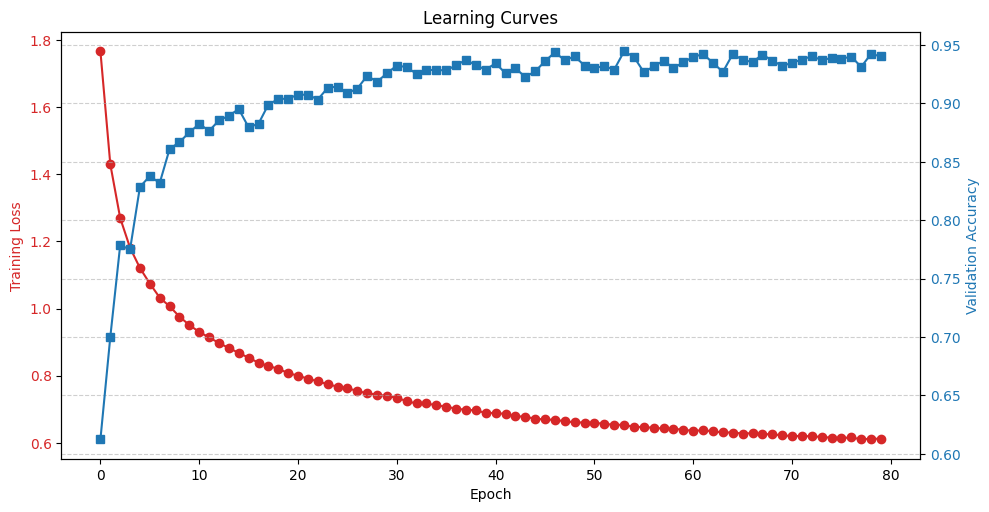

In [7]:
# Plot learning curves
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(train_losses, color=color, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)  
ax2.plot(valid_accuracies, color=color, marker='s', label='Valid Acc')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.title("Learning Curves")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Some visualisations and Interpretation questions
This code allows us to look at the filters of the first layer of convolution :

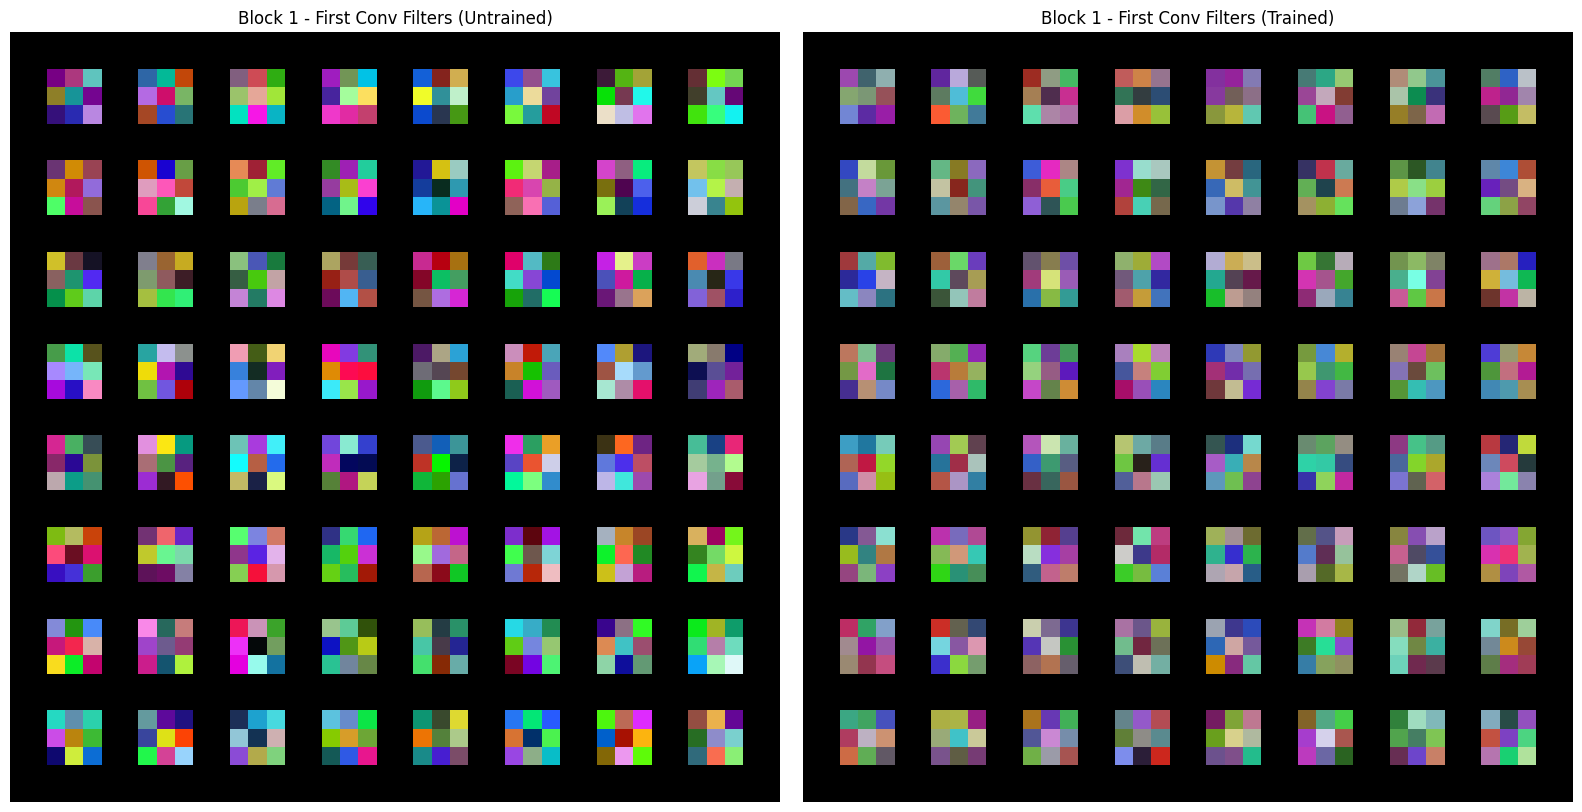

In [8]:
def visualize_filters(layer, title='Filters'):
    filters = layer.weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    grid = vutils.make_grid(filters, nrow=8, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

model = ConvNet() # Untrained model

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Untrained filters ---
# "features[0]" is your first convolutionnal layer, you might have to change it to conv1 if it was the name you gave it to
filters_untrained = model.features[0].weight.data.clone().cpu()
filters_untrained = (filters_untrained - filters_untrained.min()) / (filters_untrained.max() - filters_untrained.min())
grid_untrained = vutils.make_grid(filters_untrained, nrow=8, padding=2)
axes[0].imshow(grid_untrained.permute(1, 2, 0))
axes[0].set_title("Block 1 - First Conv Filters (Untrained)")
axes[0].axis("off")

# --- Trained filters ---
# Same thing here
filters_trained = net.features[0].weight.data.clone().cpu()
filters_trained = (filters_trained - filters_trained.min()) / (filters_trained.max() - filters_trained.min())
grid_trained = vutils.make_grid(filters_trained, nrow=8, padding=2)
axes[1].imshow(grid_trained.permute(1, 2, 0))
axes[1].set_title("Block 1 - First Conv Filters (Trained)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### What do you notice about the filters after the training ? Try to fin an interpretation about it.

Colours are a little less saturated and bright, and a little more similar to each other than the random filters at initialization. This makes sense as a consequence of the regularisation/weight-decay in the AdamW optimizer, forcing values toward zero. We can loosely see that some filters are focused on specific colour patch/gradients, and some are focused on specific edges/lines. These patterns are consistent with what we would expect from a convolutional layer learning to extract features from images - colour blobs and edges are common low-level features that would intuitively be useful for classifying images.

That being said, these observations are quite 'mild', in the sense that the filters still look decently noisy. This is explained by the fact we are looking at an initial convolutional layer that only uses small $3 \times 3$ kernel grid (common for modern deep learning architectures to not over shrink resolution straight away), and such a small dimension restricts the type of shapes/textures that can be explicitly learned in a single pass. Instead, it seems we must rely on the network depth later in the architecture to sequentially build upon these 'dumb' raw micro-edges to recognise macro structures and eventually full objects in the $32 \times 32$ image.

### Activation maps
This code snippet uses a forward hook to capture the output of the first convolutional layer of a CNN when a sample image is passed through it. The resulting activation maps show how each filter in the layer responds to different regions or features in the image.

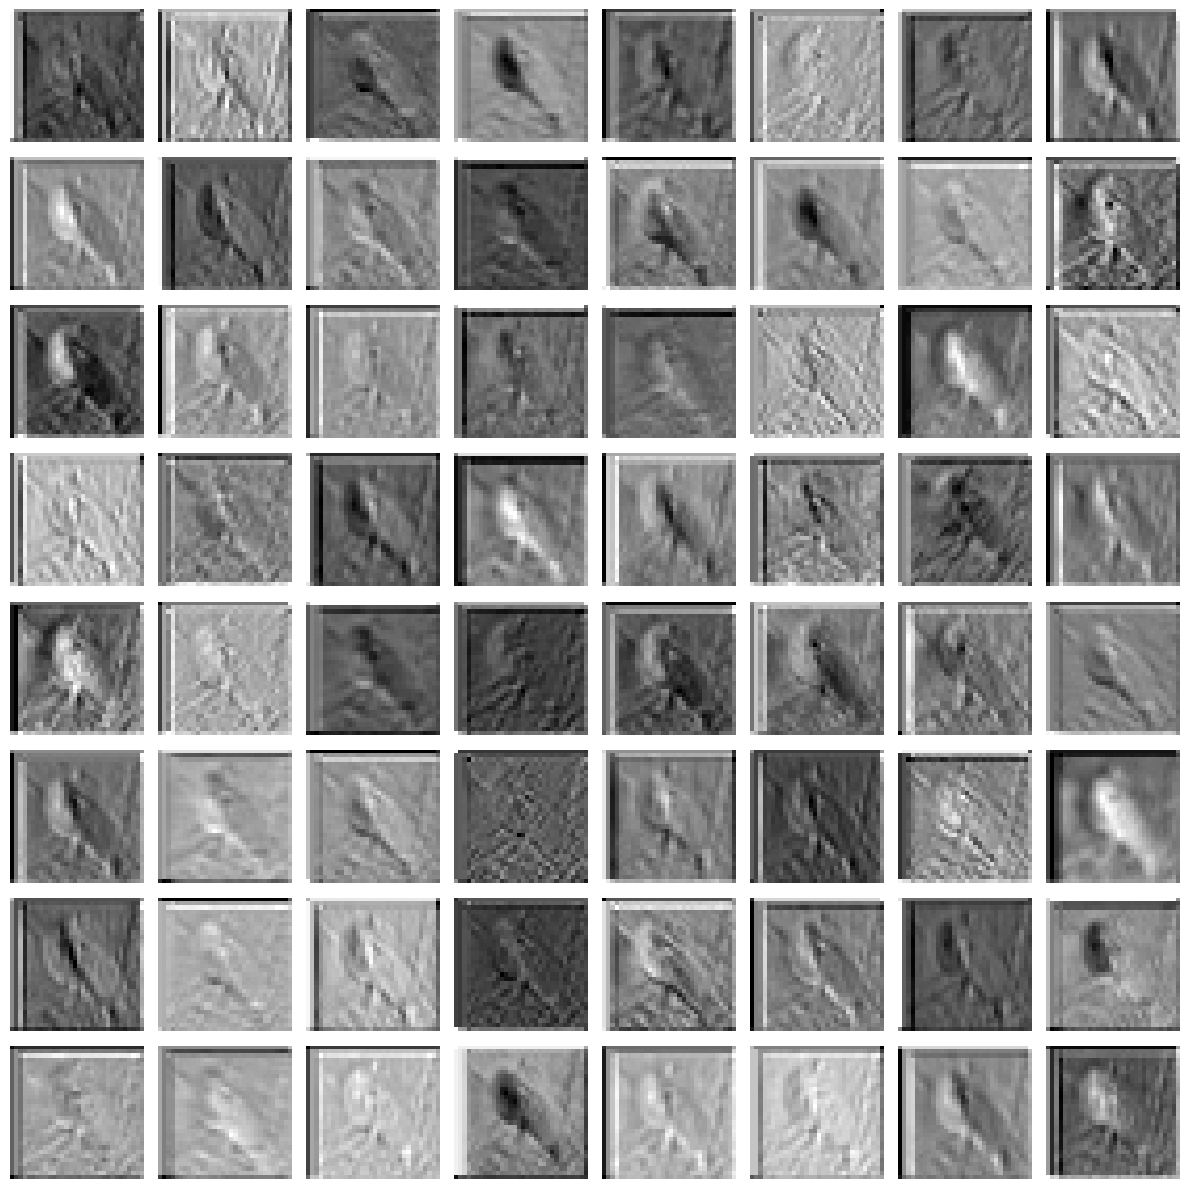

In [16]:
def get_activation(model, layer, x):
    activation = {}
    def hook_fn(module, input, output):
        activation['output'] = output.detach().cpu()
    hook = layer.register_forward_hook(hook_fn)
    model(x)
    hook.remove()
    return activation['output']

data_iter = iter(trainloader)
sample_images, sample_labels = next(data_iter)
sample_img = sample_images[0].unsqueeze(0)

# Get the feature maps after the first convolution (for example)
activation = get_activation(net, net.to('cpu').features[0], sample_img)

# Visualize a few feature maps in RGB:
def plot_feature_maps(feature_maps, n_cols=8):
    n_features = feature_maps.shape[1]
    n_rows = (n_features + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        # Extract the i-th feature map from the first (and only) sample in the batch
        act = feature_maps[0, i, :, :]
        # Normalize the activation map to [0, 1]
        act_norm = (act - act.min()) / (act.max() - act.min() + 1e-8)
        # Repeat the single channel 3 times to form an RGB image
        act_rgb = act_norm.unsqueeze(0).repeat(3, 1, 1)
        plt.imshow(act_rgb.permute(1, 2, 0))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_feature_maps(activation, n_cols=8)

# Play with the index of the chosen sample to notice more patterns and answer the question


### 1. Feature Detection
What specific features do you observe in these activation maps? Do some maps clearly highlight edges, contours, or textures? How might these features relate to the overall structure of the sample (e.g., the outline of a bird)?

Looking at the activation maps, we can clearly see the network acting as a collection of basic edge and contour detectors. Like you might expect for a picture of a bird, many maps strongly trace its outer silhouette. Some filters specifically highlight vertical edges (like the legs and neck), while others pick up on horizontal textures (like the lines in the ground/background). A few maps even seem to invert the subject or wash out the background, acting as a rudimentary form of foreground/background object segmentation. These rough outlines and structural edges are exactly the low-level building blocks the deeper layers need to piece together the full concept of a "bird".

---

### 2. Effect of Training
Consider how the activations might change after training versus an untrained (random) network. What does this tell you about the learning process?

In an untrained network, these activation maps would mostly look like pure static or blurry, random noise, because the initial filters are just arbitrary numbers that don't correspond to any real-world visual features. After training, the activations become highly structured and "fire" only for specific patterns (like those bird edges). This visually confirms that during the learning process, backpropagation explicitly forces the filters to stop responding to random pixel noise and instead tune themselves to extract only the structural geometric features that are actually useful for classifying the final image.